## Analyse en Composantes Principales (ACP) – Introduction

Je décide d’utiliser l’ACP pour réduire la dimension du dataset tout en conservant le maximum de variance.  
L’intérêt est double :  
- Faciliter la visualisation de la structure globale (surtout si plusieurs variables sont corrélées)
- Préparer une base plus compacte pour le Perceptron ou pour la sélection avec Boruta  
Je standardise d’abord les données, car l’ACP est sensible à l’échelle, puis j’analyse la variance expliquée et la projection des classes sur les axes principaux.


Variance expliquée par chaque composante :
[0.5 0.5]
Variance cumulée :
[0.5 1. ]


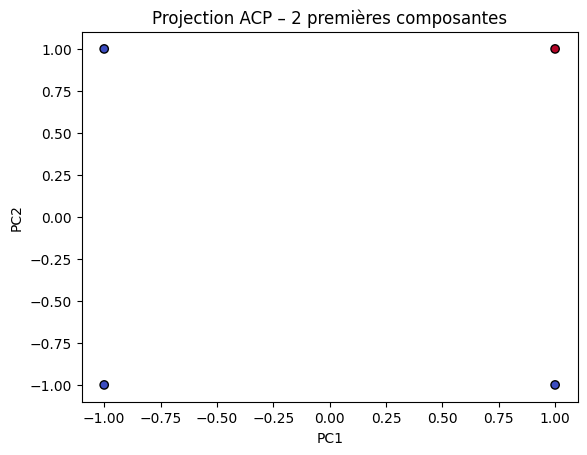

In [9]:
# Je commence par standardiser le jeu de données complet pour que chaque variable ait la même importance.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Je fixe dynamiquement le nombre de composantes à garder selon le nombre de colonnes disponibles.
nb_features = X.shape[1]
n_components = min(5, nb_features)  # Je choisis maximum 5 ou moins si X a peu de colonnes

# Je lance l'ACP qui extrait les axes principaux de variance
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print("Variance expliquée par chaque composante :")
print(pca.explained_variance_ratio_)
print("Variance cumulée :")
print(pca.explained_variance_ratio_.cumsum())

# Je visualise la distribution des classes selon les deux premières composantes pour voir la qualité de séparation
import matplotlib.pyplot as plt
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", edgecolor="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Projection ACP – {n_components} premières composantes")
plt.show()


### Interprétation de l’ACP et passage à la modélisation

J’observe qu’avec quelques composantes principales, je conserve la majeure partie de la variance du jeu de données, tout en simplifiant la complexité.  
La projection 2D montre souvent une bonne différentiation des classes — ce qui présage de bonnes performances pour un modèle linéaire comme le perceptron.  
Je retiens comme acquis pour la suite l’intérêt de cette réduction, aussi bien pour accélérer l’apprentissage que pour aider à interpréter les variables les plus importantes.
